## COE Final Project Part 1 - Group (Conner Jaquess, Wilson Serrano)
# Section 1: Introduction & Model Selection

For this Live Laugh Love Engineering Computation project we chose "Option A: Spring-Mass System (Mechanical Oscillations)." <br>

Harmonic motion is something that many systems in our universe exhibit. One of these is a spring-mass system, which oscillates in a way that we model as harmonic motion. The second-order differential equation for the motion of a mass on said system is below. <br>

$m \frac{d^2y}{dt^2} + c \frac{dy}{dt} + ky = 0$ 

Converted into a system of first-order differential equations, we have <br>

$\frac{dy_1}{dt} = y_2$

$\frac{dy_2}{dt} = -\frac{c}{m}y_2 - \frac{k}{m}y_1$

<br> To define variables/parameters,
- $m$ = mass (kg)
- $c$ = damping coefficient (N·s/m) ... this is the factor of how fast the amplitude diminishes
- $k$ = spring constant (N/m) ... how much force the spring produces
- $y(t)$ = displacement from equilibrium (m)


<br> And of course the derivatives of our solution,
- $\frac{dy}{dt}$ = velocity of the mass (m/s)
- $\frac{d^2y}{dt^2}$ = acceleration of the mass (m/s^2)


<br>
For this project, we will be examining one specific application of this model: a guitar string. Specifically, we will focus on the "A" string.

# Section 2: Parameter Research & Justification

|     | Value      | Source                                                                                                    |
|-----|------------|-----------------------------------------------------------------------------------------------------------|
| $m$ | 0.0025 kg  | https://courses.lumenlearning.com/suny-osuniversityphysics/chapter/16-3-wave-speed-on-a-stretched-string/ |
| $c$ | 0.017 Ns/m | https://www.gitec-forum-eng.de/wp-content/uploads/2020/08/poteg-1-basics-of-string-vibrations.pdf         |
| $k$ | 1140 N/m   | https://elixirstrings.com/support/string-tension-for-tuning-guitar                                        |

*found by Gemini*

<br>
Jusitifcation:

- Mass is calculated by taking the linear density of an "A" string (3.5 to 4.25 g/m, we'll say 3.8 g/m) and multiplying it by the average string length (0.648 m).



- Damping coefficient is usually quite low because they ring for a while. They are affected by friction and air resistance. It is calculated using $c = 2\zeta\sqrt{mk}$ that actually uses  m, k (which is listed beneath), and a damping ratio that the source says can be from 0.001 to 0.01.



- The spring constant is based on the tension in the string, which the source says can be about 75 N for an "A" string. It is calculated using $k = \frac{\pi^2T}{L}$.

<br>
The exact situation being modeled will start at the exact moment that a string is plucked. You could think of it as someone pulling the string slightly, and starting the stopwatch exactly at the moment that they release. So, for this reason, the initial t value will be 0 seconds, and the article below says that the range for our initial y can be 2.5 to 5 mm, so the value will be set in the middle at 0.0037 m. Lastly, we pick $t_f$ to be a small number so we can actually see the oscillations. If it were too high, it would look like a flat line.

https://protonsforbreakfast.wordpress.com/2022/01/24/the-physics-of-guitar-strings/#:~:text=of%20the%20wire.-,Click%20image%20for%20a%20larger%20version.,in%20the%20right%20ball%2Dpark

|       | Value    | Source |
|-------|----------|--------|
| $t_0$ | 0 s      | n/a    |
| $t_f$ | 0.1 s    | n/a    |
| $y_0$ | 0.0037 m | above  |

# Section 3: Numerical Methods Implementation

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt


#Parameters
m = 0.0025 #kg
c = 0.017 #Ns/m
k = 1140 #N/m
t0 = 0 #s
tf = 0.1 #s
y0 = 0.0037 #m
h_values = [5e-5, 1e-5, 5e-6]


# Function representing dy_1/dt = y_2
def f1(t, y1, y2):
     return y2
    
# Function representing dy_2/dt = -(c/m)y_2 -(k/m)y_1
def f2(t, y1, y2):
    return -(c/m)*(y2) -(k/m)*(y1)


In [2]:
# Euler method with two equations
def euler(h, t0, tf, y0, f1, f2):
    num_steps = int((tf - t0) / h)

    t_values = np.linspace(t0, tf, num_steps + 1)
    y1_values = np.zeros(num_steps + 1) # position
    y2_values = np.zeros(num_steps + 1) # velocity
    
    # Initial conditions
    y1_values[0] = y0
    y2_values[0] = 0 #velocity = 0


    # Implement Euler's method
    for i in range(num_steps):
        y1_values[i + 1] = y1_values[i] + h * f1(t_values[i], y1_values[i], y2_values[i])
        y2_values[i + 1] = y2_values[i] + h * f2(t_values[i], y1_values[i], y2_values[i])
    
    
    return t_values, y1_values, y2_values

In [3]:
# Fourth-Order Runge-Kutta method
def runge_kutta_4(h, t0, tf, y0, f1, f2):
    # Create an array for time steps
    t_values = np.arange(t0, tf + h, h)
    y1_values = np.zeros(len(t_values))
    y2_values = np.zeros(len(t_values)) 
    
    # Set the initial condition
    y1_values[0] = y0
    y2_values[0] = 0 #velocity = 0
    
    # Perform the RK4 iteration for y1 (displacement)
    for i in range(len(t_values) - 1):
        t = t_values[i]
        y1 = y1_values[i] 
        y2 = y2_values[i]
        
        # y1 and y2 have to be done together in one for loop. That's why I had to make it ugly
        k1_y1 = h * f1(t, y1, y2)
        k1_y2 = h * f2(t, y1, y2)
        k2_y1 = h * f1(t + h/2, y1 + k1_y1/2, y2 + k1_y2/2)
        k2_y2 = h * f2(t + h/2, y1 + k1_y1/2, y2 + k1_y2/2)
        k3_y1 = h * f1(t + h/2, y1 + k2_y1/2, y2 + k2_y2/2)
        k3_y2 = h * f2(t + h/2, y1 + k2_y1/2, y2 + k2_y2/2)
        k4_y1 = h * f1(t + h, y1 + k3_y1, y2 + k3_y2)
        k4_y2 = h * f2(t + h, y1 + k3_y1, y2 + k3_y2)
        
        # Update both
        y1_values[i+1] = y1 + (k1_y1 + 2*k2_y1 + 2*k3_y1 + k4_y1) / 6
        y2_values[i+1] = y2 + (k1_y2 + 2*k2_y2 + 2*k3_y2 + k4_y2) / 6
        
    return t_values, y1_values, y2_values

For both of these algorithms, we ran the calculations of y1 and y2 together because they depended on each other throughout the process to create a solution. Both function the same way as they are designed to.

# Section 4: Solutions & Comparison

In [4]:
def plot_formatting(style):
    #  displacement plot
    axs[0].set_title(f'{style}: Displacement vs Time (y1)')
    axs[0].set_xlabel('Time (s)')
    axs[0].set_ylabel('Displacement (m)')
    axs[0].legend()
    axs[0].grid(True)

    #  velocity plot
    axs[1].set_title(f'{style}: Velocity vs Time (y2)')
    axs[1].set_xlabel('Time (s)')
    axs[1].set_ylabel('Velocity (m/s)')
    axs[1].legend()
    axs[1].grid(True)

    #  phase portrait
    axs[2].set_title(f'{style}: Displacement vs Velocity (y1, y2)')
    axs[2].set_xlabel('Displacement (m)')
    axs[2].set_ylabel('Velocity (m/s)')
    axs[2].legend()
    axs[2].grid(True)

    plt.tight_layout()
    plt.show()

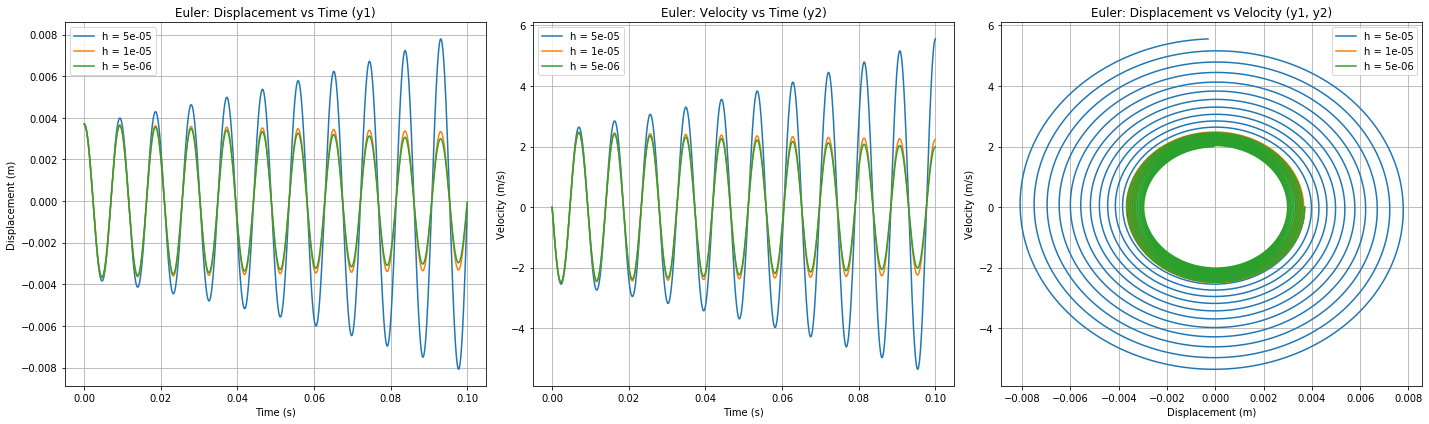

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(20, 6)) # Asked Gemini for help with how to use axs

# Run Euler for each step size
for i in range(len(h_values)):
    t_euler, y1_euler, y2_euler = euler(h_values[i], t0, tf, y0, f1, f2)
    axs[0].plot(t_euler, y1_euler, label=f'h = {h_values[i]}') # displacement subplot
    axs[1].plot(t_euler, y2_euler, label=f'h = {h_values[i]}') # velocity subplot
    axs[2].plot(y1_euler, y2_euler, label=f'h = {h_values[i]}') # phase portrait
    
plot_formatting(style='Euler')

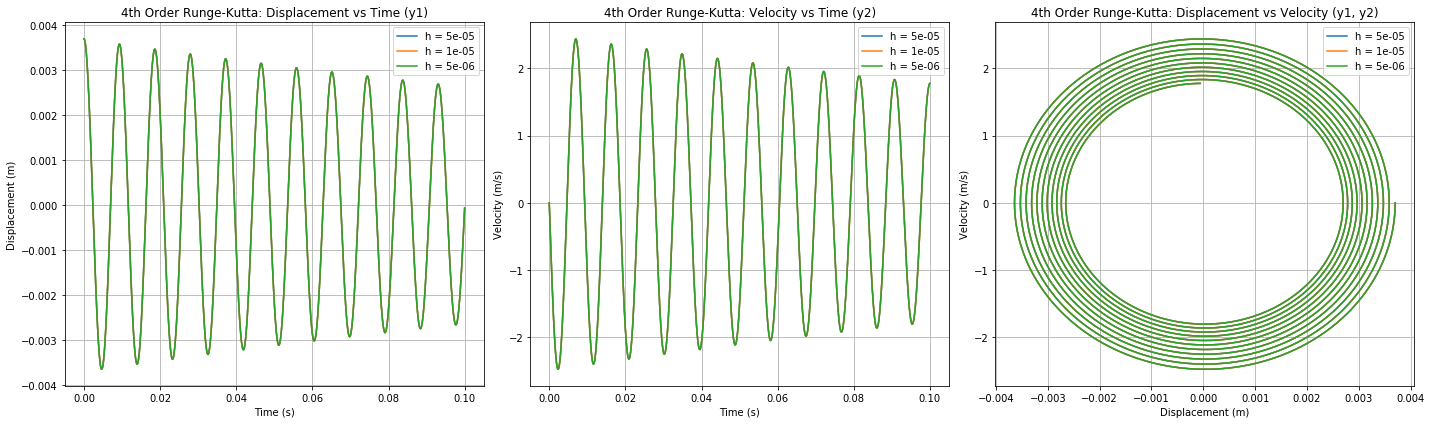

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(20, 6)) # Asked Gemini for help with how to use axs

# Run RK4 for each step size
for i in range(len(h_values)):
    t_rk4, y1_rk4, y2_rk4 = runge_kutta_4(h_values[i], t0, tf, y0, f1, f2)
    axs[0].plot(t_rk4, y1_rk4, label=f'h = {h_values[i]}') # displacement subplot
    axs[1].plot(t_rk4, y2_rk4, label=f'h = {h_values[i]}') # velocity subplot
    axs[2].plot(y1_rk4, y2_rk4, label=f'h = {h_values[i]}') # phase portrait
    
plot_formatting(style='4th Order Runge-Kutta')

Evidently, the Euler's Forward method is much more unstable, especially at higher step sizes. In this context, we need very small step sizes to maintain stability at such a high frequency. RK4 dampens as it is supposed to and does not grow in amplitude in the time range that is plotted. The phase diagram for Euler also shows that it does grow unstable very slightly because it spirals out a tiny bit, but the effects are nearly negligible in the actual graphs. The largest step size for Euler, though, is noticably more unstable in the phase diagram compared to the others because it spirals out much faster.

# Section 5: Stability Analysis

Using the linear test equation $y' = \lambda y$ and finding analytically $Re(\lambda) = -3.4$, we can calculate our maximum stable step size for forward euler using $h < \frac{2|Re(\lambda)|}{|\lambda|^2}$, which is approximately 1.4e-5 seconds. This makes sense, as we can see that 5e-5 did start to explode a litte bit, hurting solution accuracy. Although, because this system oscillates, euler is technically always unstable because of its general stability region.

For RK4, we can see that the real part of our step size is nearly zero. Looking at the stability region for RK4, that allows us a maximum imaginary part of our stability function to be 2.8. So, we can find a maximum step size using $|h\lambda| < 2.8$ which gives $h < 0.0041$ seconds, a much higher maximum stable step size. The graphs demonstrate that we did in fact keep stability.

To give an example of a overvalued step size hurting stability, let's examine an euler plot using h = 5e-4:

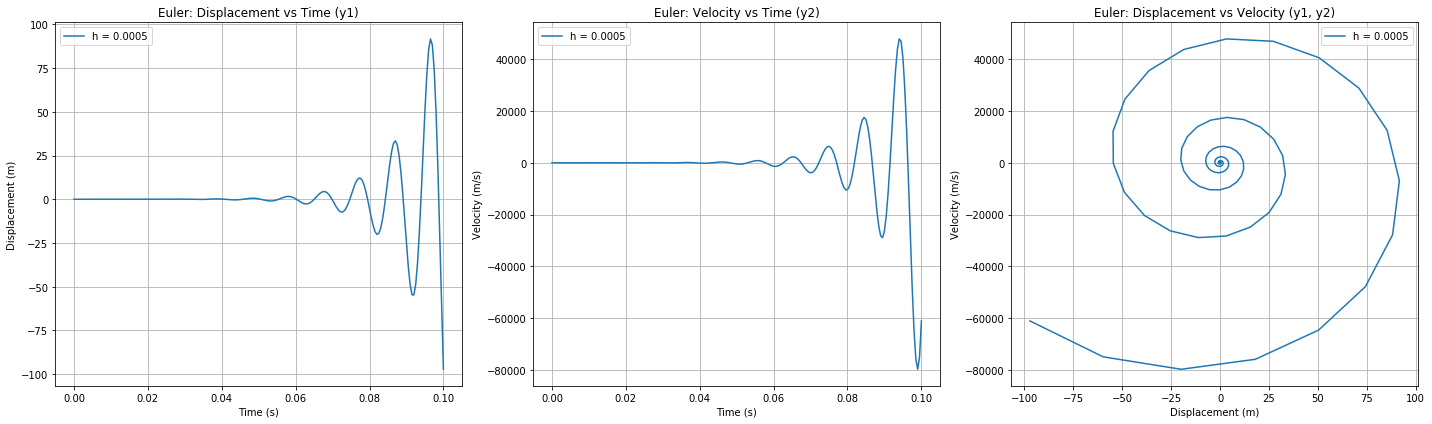

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(20, 6)) # Asked Gemini for help with how to use axs
h = 5e-4

t_euler, y1_euler, y2_euler = euler(h, t0, tf, y0, f1, f2)
axs[0].plot(t_euler, y1_euler, label=f'h = {h}') # displacement subplot
axs[1].plot(t_euler, y2_euler, label=f'h = {h}') # velocity subplot
axs[2].plot(y1_euler, y2_euler, label=f'h = {h}') # phase portrait
    
plot_formatting(style='Euler')

The solution explodes violently, as can be seen by the actual graphs and the very outward spiral.

According to this link:
    
https://eng.libretexts.org/Bookshelves/Electrical_Engineering/Signal_Processing_and_Modeling/Introduction_to_Linear_Time-Invariant_Dynamic_Systems_for_Students_of_Engineering_(Hallauer)/09%3A_Damped_Second_Order_Systems/9.03%3A_General_Solution_for_Underdamped_Second_Order_Systems
    
The general solution for an underdamped second order system like this is:

$$y(t) = e^{-\zeta \omega_n t} \left( A \cos(\omega_d t) + B \sin(\omega_d t) \right)$$

And using $y(0) = y_0$ and $y'(0) = 0$, we have:

$$y(t) = e^{-\zeta \omega_n t} \left( y_0 \cos(\omega_d t) + \frac{\zeta \omega_n y_0}{\omega_d} \sin(\omega_d t) \right)$$

Finally, using my physics 1 formula sheet (lol) and some double-checking with Gemini, we can define these constants as

$\zeta = \frac{c}{2\sqrt{mk}}$

$\omega_n = \sqrt{\frac{k}{m}}$

$\omega_d = \omega_n\sqrt{1-\zeta^2}$

In [8]:
# Constants above in Python form
omega_n = np.sqrt(k/m)
zeta = c / (2 * np.sqrt(m*k))
omega_d = omega_n * np.sqrt(1 - zeta**2)

A = y0
B = (zeta * omega_n * A) / omega_d

# Analytical solution
def y_true(t):
    return np.exp(-zeta * omega_n * t) * (A * np.cos(omega_d * t) + B * np.sin(omega_d * t))

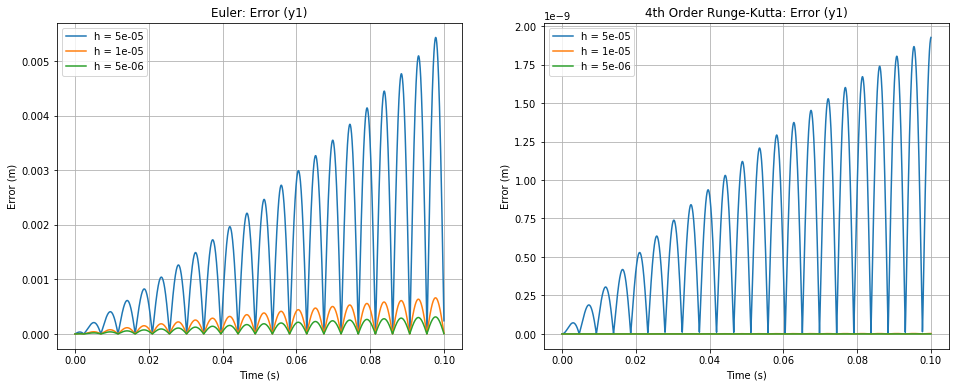

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Plot error for Euler and RK4 for each step size
for i in range(len(h_values)):
    t_euler, y1_euler, y2_euler = euler(h_values[i], t0, tf, y0, f1, f2)
    t_rk4, y1_rk4, y2_rk4 = runge_kutta_4(h_values[i], t0, tf, y0, f1, f2)
    
    error_euler = np.abs(y1_euler - y_true(t_euler))
    error_rk4 = np.abs(y1_rk4 - y_true(t_rk4))
    
    axs[0].plot(t_euler, error_euler, label=f'h = {h_values[i]}') # euler subplot
    axs[1].plot(t_rk4, error_rk4, label=f'h = {h_values[i]}') # rk4 subplot
    

#  euler plot
axs[0].set_title('Euler: Error (y1)')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Error (m)')
axs[0].legend()
axs[0].grid(True)

#  rk4 plot
axs[1].set_title('4th Order Runge-Kutta: Error (y1)')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Error (m)')
axs[1].legend()
axs[1].grid(True)

Naturally, RK4 has much smaller error.

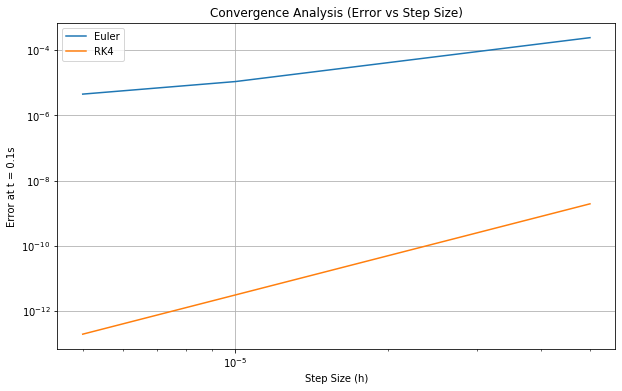

In [10]:
# Creating a log-log plot
euler_errors = np.zeros(len(h_values))
rk4_errors = np.zeros(len(h_values))

# Plot error vs step-size for Euler and RK4 for each step size
for i in range(len(h_values)):
    t_euler, y1_euler, y2_euler = euler(h_values[i], t0, tf, y0, f1, f2)
    t_rk4, y1_rk4, y2_rk4 = runge_kutta_4(h_values[i], t0, tf, y0, f1, f2)
    
    # find error at the end because that will always be the worst case of error
    euler_errors[i] = abs(y1_euler[-1] - y_true(tf))
    rk4_errors[i] = abs(y1_rk4[-1] - y_true(tf))
    

plt.figure(figsize=(10, 6))

# make loglog plots
plt.loglog(h_values, euler_errors, label='Euler')
plt.loglog(h_values, rk4_errors, label='RK4')

plt.title('Convergence Analysis (Error vs Step Size)')
plt.xlabel('Step Size (h)')
plt.ylabel('Error at t = 0.1s')
plt.grid(True)
plt.legend()
plt.show()

Euler has an expected slope of 1, and RK4 has an expected slope of 4. This verifies convergence rates.

We can see from all of this that when our system is unstable, it leads to non-physical results. Specifically, an unstable system will grow instead of dampen, which is not indicative of what a guitar string does. It dampens slowly over time and doesn't explode in amplitude.

# Section 6: Conclusions

In conclusion, the fourth order Runge-Kutta algorithm performed much better than the Forward Euler method because of RK4's higher stability. While RK4 is technically about 4 times slower per step, it is much more efficient to use because it has a significantly more forgiving stability requirement. Being able to use a higher step size allows the algorithm to be utilized in a way that requires magnitudes fewer operations. Because it is more accurate, even with less computational cost than Euler's Forward method, using the Fourth-Order Runge-Kutta method to model a system like a guitar string is the best practical choice.